In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("Fraud.csv")

In [3]:
df.shape

(6362620, 11)

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

In [9]:
df['isFraud'].value_counts(normalize=True) * 100

0    99.870918
1     0.129082
Name: isFraud, dtype: float64

In [10]:
df.duplicated().sum()

0

In [11]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [12]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

In [13]:
df['amount'].describe()

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64

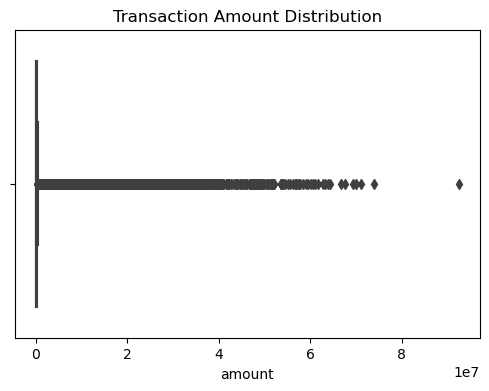

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['amount'])
plt.title("Transaction Amount Distribution")
plt.show()

In [15]:
df['log_amount'] = np.log1p(df['amount'])

In [16]:
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']

In [17]:
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [18]:
df.drop(['amount'], axis=1, inplace=True)

In [19]:
df['type'].value_counts()

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64

In [20]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [21]:
df.head()

,step,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,log_amount,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,170136.0,160296.36,0.0,0.0,0,0,9.194276,9839.64,0.0,0,0,1,0
1,1,21249.0,19384.72,0.0,0.0,0,0,7.531166,1864.28,0.0,0,0,1,0
2,1,181.0,0.00,0.0,0.0,1,0,5.204007,181.00,0.0,0,0,0,1
3,1,181.0,0.00,21182.0,0.0,1,0,5.204007,181.00,-21182.0,1,0,0,0
4,1,41554.0,29885.86,0.0,0.0,0,0,9.364703,11668.14,0.0,0,0,1,0


In [22]:
df.shape

(6362620, 14)

In [23]:
# target variable
y = df['isFraud']

# Drop target and non-predictive column from features
X = df.drop(['isFraud', 'isFlaggedFraud'], axis=1)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [25]:
y_train.value_counts(normalize=True) * 100

0    99.87092
1     0.12908
Name: isFraud, dtype: float64

In [26]:
y_val.value_counts(normalize=True) * 100

0    99.870913
1     0.129087
Name: isFraud, dtype: float64

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42
)

In [28]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [29]:
# Predicted class labels
y_pred = rf_model.predict(X_val)

# Predicted probabilities 
y_pred_proba = rf_model.predict_proba(X_val)[:, 1]

In [31]:
from sklearn.metrics import confusion_matrix
#TN FP  FN TP
cm = confusion_matrix(y_val, y_pred)
cm

array([[1906269,      53],
       [    486,    1978]], dtype=int64)

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.97      0.80      0.88      2464

    accuracy                           1.00   1908786
   macro avg       0.99      0.90      0.94   1908786
weighted avg       1.00      1.00      1.00   1908786



In [33]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_val, y_pred_proba)
roc_auc

0.9952542259821752

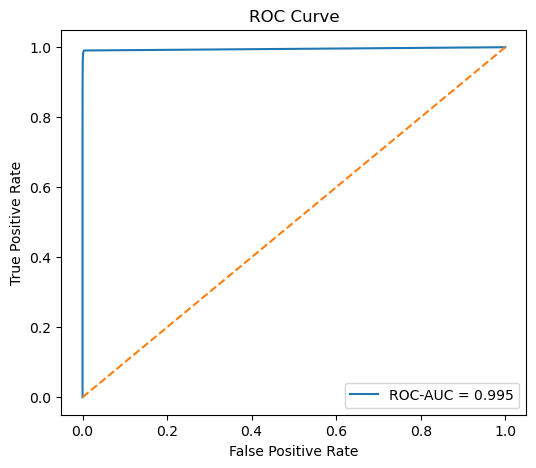

In [34]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

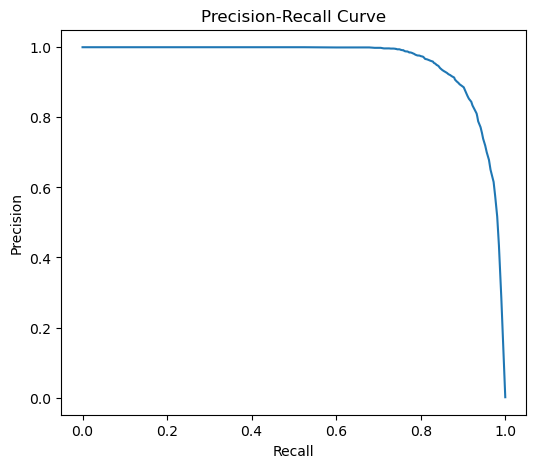

In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [36]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
6,balance_diff_orig,0.318887
1,oldbalanceOrg,0.179406
2,newbalanceOrig,0.119262
5,log_amount,0.116939
7,balance_diff_dest,0.059816
11,type_TRANSFER,0.052479
10,type_PAYMENT,0.046434
0,step,0.035671
4,newbalanceDest,0.029798
3,oldbalanceDest,0.026143


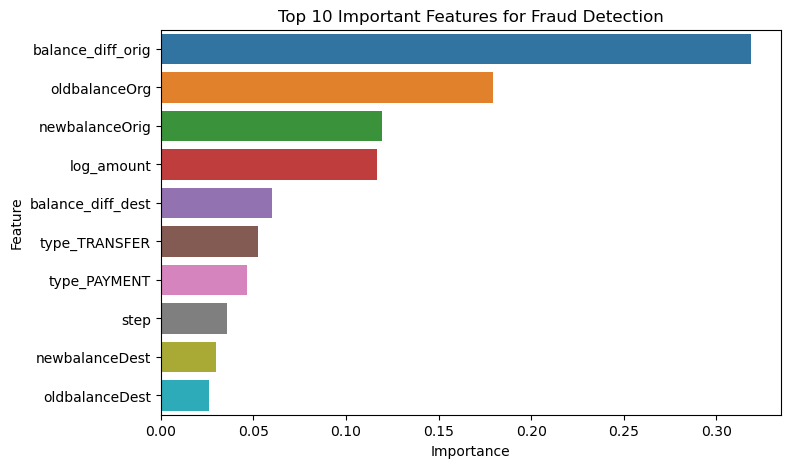

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features for Fraud Detection")
plt.show()